# Function 8: Bayesian Optimisation (8D)
### Imperial College — Bayesian Optimisation Capstone

In [1]:
# Cell 2: Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [2]:
# Cell 3: Load data and inspect
# Function 8: ML model with 8 hyperparameters, Maximise.
# Dimensions: learning rate, batch size, layers, dropout, regularisation,
#             activation function, optimiser type, weight range.

X = np.load('../data/function_8/initial_inputs.npy')
Y = np.load('../data/function_8/initial_outputs.npy')

#Set this once and never change it — it's the size of the original file
INITIAL_SIZE = 40   #change to 10 for F1/F2, 15 for F3, 20 for F5/F6, 30 for F4/F7
current_week = len(Y) - INITIAL_SIZE + 1
print(f'Current week : {current_week}')
print(f'Data points  : {len(Y)} ({INITIAL_SIZE} initial + {len(Y)-INITIAL_SIZE} added)')

print(f'Input  shape : {X.shape}   (n_samples x n_dimensions)')
print(f'Output shape : {Y.shape}  (n_samples,)')
print()

# Sort descending by Y value
X_list = list(X)
Y_list = list(Y)
pairs = sorted(zip(Y_list, X_list), reverse=True)
Y_sorted = [p[0] for p in pairs]
X_sorted = [p[1] for p in pairs]

print('=' * 110)
print('  All observations (sorted descending by Y)')
print('=' * 110)
for i, (y_val, x_val) in enumerate(zip(Y_sorted, X_sorted)):
    marker = '  <-- best' if i == 0 else ''
    x_str = ', '.join([f'{v:.5f}' for v in x_val])
    print(f'  [{i+1:2d}]  X = [{x_str}]   Y = {y_val:+.6e}{marker}')
print('=' * 110)

best_Y = Y_sorted[0]
best_X = np.array(X_sorted[0])
x_str_best = ', '.join([f'{v:.8f}' for v in best_X])
print(f'\n  Best Y*  = {best_Y:.6e}')
print(f'  Best X*  = [{x_str_best}]')

Current week : 1
Data points  : 40 (40 initial + 0 added)
Input  shape : (40, 8)   (n_samples x n_dimensions)
Output shape : (40,)  (n_samples,)

  All observations (sorted descending by Y)
  [ 1]  X = [0.05645, 0.06596, 0.02293, 0.03879, 0.40394, 0.80106, 0.48831, 0.89308]   Y = +9.598482e+00  <-- best
  [ 2]  X = [0.19264, 0.63068, 0.41680, 0.49053, 0.79609, 0.65457, 0.27624, 0.29552]   Y = +9.344274e+00
  [ 3]  X = [0.48125, 0.10246, 0.21949, 0.67732, 0.24751, 0.24434, 0.16382, 0.71596]   Y = +9.183005e+00
  [ 4]  X = [0.14512, 0.11933, 0.42089, 0.38761, 0.15542, 0.87517, 0.51056, 0.72861]   Y = +9.141639e+00
  [ 5]  X = [0.04433, 0.01358, 0.25820, 0.57764, 0.05128, 0.15856, 0.59103, 0.07795]   Y = +9.013075e+00
  [ 6]  X = [0.14355, 0.93741, 0.23232, 0.00904, 0.41458, 0.40933, 0.55378, 0.20584]   Y = +8.976554e+00
  [ 7]  X = [0.02895, 0.02828, 0.48137, 0.61317, 0.67266, 0.02211, 0.60148, 0.52489]   Y = +8.830745e+00
  [ 8]  X = [0.33895, 0.56693, 0.37675, 0.09892, 0.65945, 0.24555

In [3]:
# Cell 4: Fit GP with log-transformed Y

# Log-transform to handle extreme scale differences across observations
Y_fit = np.log(np.abs(Y) + 1e-300)

# Fixed RBF kernel (course style — no ConstantKernel, no optimisation)
kernel = RBF(length_scale=0.1, length_scale_bounds='fixed')
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
gp.fit(X, Y_fit)

print('=' * 62)
print('  GP Fitting Results')
print('=' * 62)
print(f'  Kernel                   : {gp.kernel_}')
print(f'  Log-marginal-likelihood  : {gp.log_marginal_likelihood_value_:.4f}')
print()

# Sanity check: predict at best known point
pred_mean, pred_std = gp.predict(best_X.reshape(1, -1), return_std=True)
actual_log = np.log(np.abs(best_Y) + 1e-300)
x_str_best = ', '.join([f'{v:.6f}' for v in best_X])
print('  Sanity check at best known X*:')
print(f'    X*                     = [{x_str_best}]')
print(f'    GP predicted mean      = {pred_mean[0]:.4f}  (log-space)')
print(f'    Actual log(|Y*|)       = {actual_log:.4f}  (log-space)')
print(f'    GP predicted std       = {pred_std[0]:.8f}')
print('=' * 62)

  GP Fitting Results
  Kernel                   : RBF(length_scale=0.1)
  Log-marginal-likelihood  : -120.9874

  Sanity check at best known X*:
    X*                     = [0.056447, 0.065956, 0.022929, 0.038786, 0.403935, 0.801055, 0.488307, 0.893085]
    GP predicted mean      = 2.2616  (log-space)
    Actual log(|Y*|)       = 2.2616  (log-space)
    GP predicted std       = 0.00001000


In [4]:
# Cell 5: UCB acquisition over random search (50,000 points in 8D)
# High dimensionality requires large random search to adequately cover the space.

np.random.seed(42)
X_grid = np.random.uniform(0, 1, size=(50000, 8))  # shape (50000, 8)

# GP predictions across the random grid
post_mean, post_std = gp.predict(X_grid, return_std=True)

# UCB acquisition: mean + beta * std
beta = 2.5  #Higher beta = more exploration at early stage (Week 1, sparse data)
acquisition = post_mean + beta * post_std  # shape (50000,)

# Next query = grid point with highest UCB
best_idx = np.argmax(acquisition)
next_x   = X_grid[best_idx]
next_acq = acquisition[best_idx]

# Portal submission string
portal_string = '-'.join([f'{v:.6f}' for v in next_x])

next_x_str = ', '.join([f'{v:.6f}' for v in next_x])
print('=' * 62)
print('  UCB Acquisition  (beta = 2.5, random search 50,000 pts)')
print('=' * 62)
print(f'  Grid size            : {len(X_grid)} points (random uniform, 8D)')
print(f'  Max UCB value        : {next_acq:.4f}')
print(f'  Next query point     : [{next_x_str}]')
print()
print('  Portal submission string:')
print(f'  >>> {portal_string} <<<')
print('=' * 62)

  UCB Acquisition  (beta = 2.5, random search 50,000 pts)
  Grid size            : 50000 points (random uniform, 8D)
  Max UCB value        : 3.1167
  Next query point     : [0.816815, 0.656459, 0.258882, 0.854757, 0.737459, 0.233756, 0.838932, 0.820863]

  Portal submission string:
  >>> 0.816815-0.656459-0.258882-0.854757-0.737459-0.233756-0.838932-0.820863 <<<


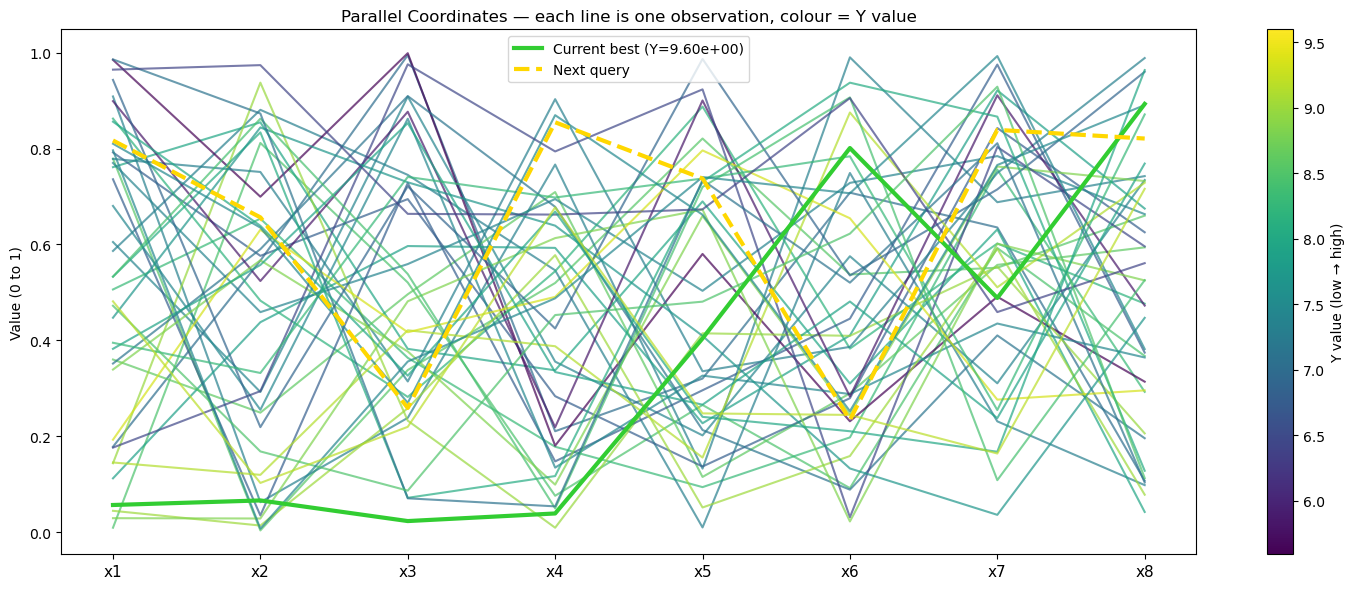

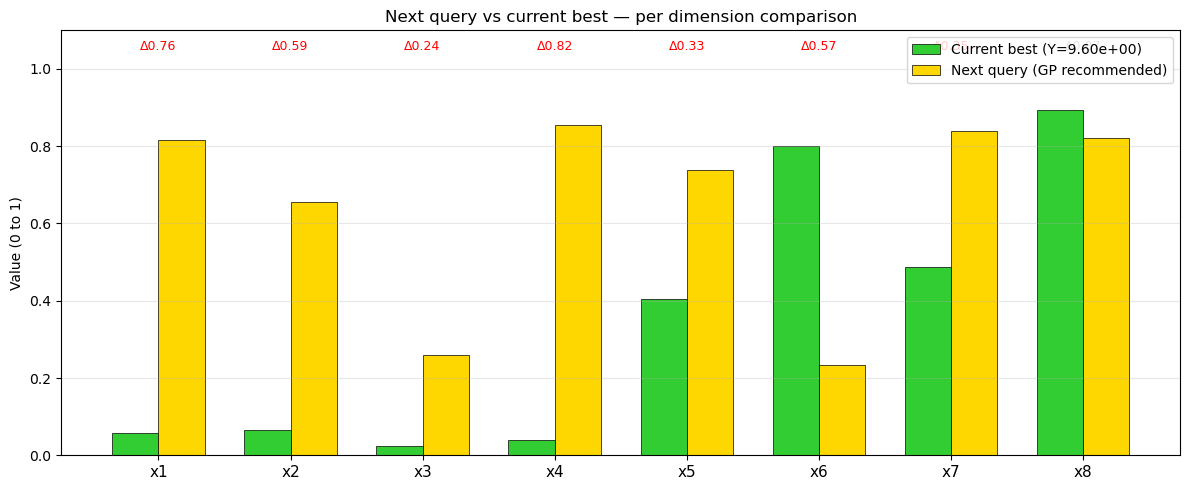

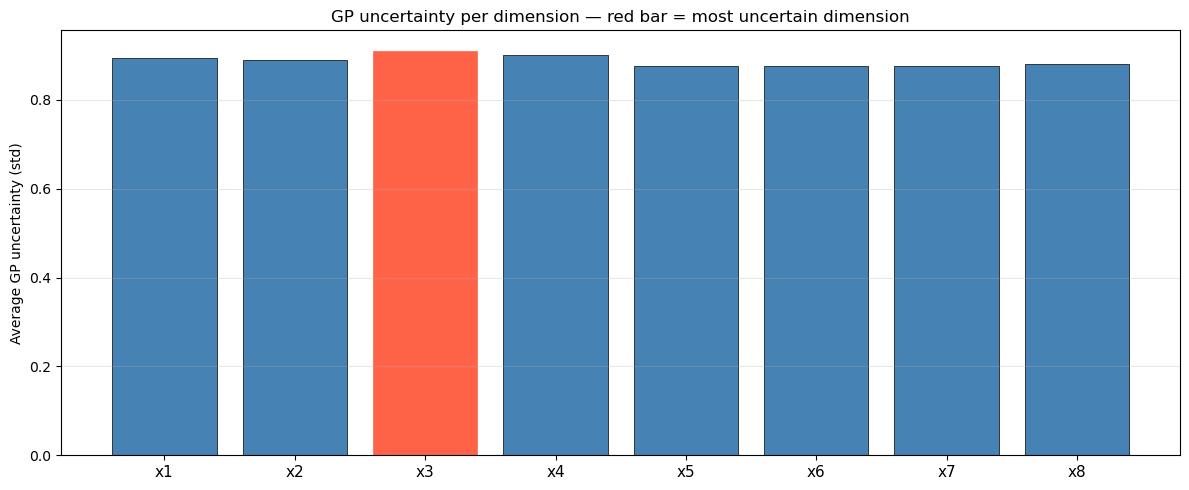

In [5]:
# Cell 6: Visualisation — three high-dimensional plots
n_dims = X.shape[1]

# ── Plot 1: Parallel Coordinates ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

# Normalise Y for colouring — 0=worst, 1=best
Y_norm = (Y - Y.min()) / (Y.max() - Y.min() + 1e-300)
cmap = plt.cm.viridis

# Plot each observed point as a line across all dimensions
for i in range(len(X)):
    ax.plot(range(n_dims), X[i], color=cmap(Y_norm[i]),
            alpha=0.7, linewidth=1.5)

# Plot current best as thick green line
ax.plot(range(n_dims), best_X, color='limegreen',
        linewidth=3, label=f'Current best (Y={best_Y:.2e})', zorder=5)

# Plot next query as thick gold line
ax.plot(range(n_dims), next_x, color='gold', linewidth=3,
        linestyle='--', label=f'Next query', zorder=6)

ax.set_xticks(range(n_dims))
ax.set_xticklabels([f'x{i+1}' for i in range(n_dims)], fontsize=11)
ax.set_ylabel('Value (0 to 1)')
ax.set_title('Parallel Coordinates — each line is one observation, colour = Y value')
ax.legend()
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array(Y)
plt.colorbar(sm, ax=ax, label='Y value (low → high)')
plt.tight_layout()
plt.show()

# ── Plot 2: Next query vs current best bar chart ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x_positions = np.arange(n_dims)
width = 0.35

ax.bar(x_positions - width/2, best_X, width,
       label=f'Current best (Y={best_Y:.2e})',
       color='limegreen', edgecolor='black', linewidth=0.5)
ax.bar(x_positions + width/2, next_x, width,
       label='Next query (GP recommended)',
       color='gold', edgecolor='black', linewidth=0.5)

ax.set_xticks(x_positions)
ax.set_xticklabels([f'x{i+1}' for i in range(n_dims)], fontsize=11)
ax.set_ylabel('Value (0 to 1)')
ax.set_ylim(0, 1.1)
ax.set_title('Next query vs current best — per dimension comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Highlight dimensions where next query differs most from best
diffs = np.abs(next_x - best_X)
for i, d in enumerate(diffs):
    ax.text(i, 1.05, f'Δ{d:.2f}', ha='center', fontsize=9,
            color='red' if d > 0.2 else 'gray')

plt.tight_layout()
plt.show()

# ── Plot 3: GP uncertainty per dimension (which dims matter most) ─────────────
# Sample points varying one dimension at a time, others fixed at best_X
fig, ax = plt.subplots(figsize=(12, 5))

uncertainty_per_dim = []
x_line = np.linspace(0, 1, 50)

for dim in range(n_dims):
    X_slice = np.tile(best_X, (50, 1))  # repeat best_X 50 times
    X_slice[:, dim] = x_line            # vary only this dimension
    _, std_slice = gp.predict(X_slice, return_std=True)
    uncertainty_per_dim.append(std_slice.mean())  # average uncertainty

bars = ax.bar(range(n_dims), uncertainty_per_dim,
              color='steelblue', edgecolor='black', linewidth=0.5)

# Highlight the dimension with highest uncertainty
max_dim = np.argmax(uncertainty_per_dim)
bars[max_dim].set_color('tomato')

ax.set_xticks(range(n_dims))
ax.set_xticklabels([f'x{i+1}' for i in range(n_dims)], fontsize=11)
ax.set_ylabel('Average GP uncertainty (std)')
ax.set_title('GP uncertainty per dimension — red bar = most uncertain dimension')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Cell 7: Summary

next_x_str = ', '.join([f'{v:.6f}' for v in next_x])
best_x_str = ', '.join([f'{v:.6f}' for v in best_X])

print('=' * 62)
print('  SUMMARY — Bayesian Optimisation Results')
print('=' * 62)
print(f'  Function             : 8D ML Hyperparameter Tuning')
print(f'  Dims                 : lr, batch_size, layers, dropout, reg,')
print(f'                         activation_fn, optimiser_type, weight_range')
print(f'  Objective            : Maximise')
print(f'  Kernel               : RBF(length_scale=0.1, fixed)')
print(f'  Acquisition function : UCB  (beta = 2.5)')
print(f'  Y transform          : log(|Y| + 1e-300)')
print(f'  Grid search          : Random uniform (50,000 points, 8D)')
print(f'  Current week         : {current_week}')
print(f'  Observations         : {len(Y)} total ({len(Y)-INITIAL_SIZE} added so far)')
print()
print(f'  Current best X*      : [{best_x_str}]')
print(f'  Current best Y*      : {best_Y:.6e}')
print()
print(f'  Next query point     : [{next_x_str}]')
print()
print('  Portal submission string:')
print(f'  >>> {portal_string} <<<')
print('=' * 62)

  SUMMARY — Bayesian Optimisation Results
  Function             : 8D ML Hyperparameter Tuning
  Dims                 : lr, batch_size, layers, dropout, reg,
                         activation_fn, optimiser_type, weight_range
  Objective            : Maximise
  Kernel               : RBF(length_scale=0.1, fixed)
  Acquisition function : UCB  (beta = 2.5)
  Y transform          : log(|Y| + 1e-300)
  Grid search          : Random uniform (50,000 points, 8D)
  Current week         : 1
  Observations         : 40 total (0 added so far)

  Current best X*      : [0.056447, 0.065956, 0.022929, 0.038786, 0.403935, 0.801055, 0.488307, 0.893085]
  Current best Y*      : 9.598482e+00

  Next query point     : [0.816815, 0.656459, 0.258882, 0.854757, 0.737459, 0.233756, 0.838932, 0.820863]

  Portal submission string:
  >>> 0.816815-0.656459-0.258882-0.854757-0.737459-0.233756-0.838932-0.820863 <<<
